# 톤을 절제한 보색 vs 절제하지 않은 보색

『그대로 갖다 쓰는 색깔 조합 16가지』에서 소개한 두 조합은 **둘 다 보색 관계**다.

| 조합 | HEX | 톤 관계 |
|---|---|---|
| 세이지그린 & 연분홍 | `#719470` / `#E0B3B6` | 대칭 — 둘 다 **저채도**로 톤을 절제 |
| 오렌지 & 틸블루 | `#D96629` / `#0093A5` | 대칭 — **톤 절제 없음**, 보색 대비 그대로 |

영상의 핵심 원리는 두 색의 관계를 **(1) 색상환 각도**와 **(2) 톤(명도·채도)** 두 축으로
분리해서 보는 것이다. 이 스크립트는 그 두 축을 실제 숫자로 확인한다.

- 색상각 차이 $\Delta H = \min(|H_1 - H_2|,\ 360 - |H_1 - H_2|)$ — 보색이면 $180°$ 근방
- 채도 $S$, 명도 $L$ (HSL 기준) — "톤"이 절제됐는지 확인
- 대비 강도 지표: CIELAB 색차 $\Delta E^*_{ab} = \sqrt{\Delta L^{*2} + \Delta a^{*2} + \Delta b^{*2}}$

In [1]:
import colorsys
import math


def _show(fig):
    try:
        from IPython import get_ipython

        if get_ipython() is not None:
            fig.show()
    except ImportError:
        pass


PAIRS = {
    "세이지그린 & 연분홍 (톤 절제)": [("세이지그린", "#719470"), ("연분홍", "#E0B3B6")],
    "오렌지 & 틸블루 (톤 절제 없음)": [("오렌지", "#D96629"), ("틸블루", "#0093A5")],
}


def hex_to_rgb01(hex_str):
    h = hex_str.lstrip("#")
    return tuple(int(h[i : i + 2], 16) / 255 for i in (0, 2, 4))


for title, colors in PAIRS.items():
    print(title)
    for name, hx in colors:
        print(f"  {name:6s} {hx}  RGB(0~1) = {tuple(round(c, 3) for c in hex_to_rgb01(hx))}")

세이지그린 & 연분홍 (톤 절제)
  세이지그린  #719470  RGB(0~1) = (0.443, 0.58, 0.439)
  연분홍    #E0B3B6  RGB(0~1) = (0.878, 0.702, 0.714)
오렌지 & 틸블루 (톤 절제 없음)
  오렌지    #D96629  RGB(0~1) = (0.851, 0.4, 0.161)
  틸블루    #0093A5  RGB(0~1) = (0.0, 0.576, 0.647)


## 1. 색상각 차이 — 두 쌍 모두 보색 근방인가?

`colorsys.rgb_to_hls`로 색상 $H$를 구하고, 원형 거리로 각도 차이를 계산한다.
보색이면 $\Delta H \approx 180°$ 여야 한다.

In [2]:
def hue_deg(hex_str):
    h, _l, _s = colorsys.rgb_to_hls(*hex_to_rgb01(hex_str))
    return h * 360


def hue_diff(h1, h2):
    d = abs(h1 - h2) % 360
    return min(d, 360 - d)


for title, colors in PAIRS.items():
    h1, h2 = (hue_deg(hx) for _, hx in colors)
    print(f"{title}: H1={h1:6.1f}°, H2={h2:6.1f}°, ΔH={hue_diff(h1, h2):6.1f}°")

세이지그린 & 연분홍 (톤 절제): H1= 118.3°, H2= 356.0°, ΔH= 122.3°
오렌지 & 틸블루 (톤 절제 없음): H1=  20.8°, H2= 186.5°, ΔH= 165.8°


두 쌍 모두 색상환에서 서로 **반대편**에 놓여 있다 (오렌지·틸블루는 $166°$로 거의 정확한 보색,
세이지그린·연분홍은 $122°$ — 화가의 RYB 색상환에서는 녹색과 빨강/분홍이 마주보는 보색이고
HSL(RGB 색상환)로 재면 각도가 조금 줄어든다). 즉 **색상 축에서는 둘 다 '대비가 나야 하는' 조합**이다.
차이는 다음 단계, 톤에서 생긴다.

## 2. 톤(채도·명도) 표 — 어느 쌍이 톤을 절제했나?

HSL의 $S$(채도)와 $L$(명도)를 나란히 놓는다. "톤이 죽어 있다"는 표현은 곧 **채도 $S$가 낮다**는 뜻이다.

In [3]:
def hsl(hex_str):
    h, l, s = colorsys.rgb_to_hls(*hex_to_rgb01(hex_str))
    return h * 360, s * 100, l * 100


print(f"{'색':8s} {'HEX':8s} {'H(°)':>7s} {'S(%)':>7s} {'L(%)':>7s}")
for title, colors in PAIRS.items():
    s_vals = []
    for name, hx in colors:
        h, s, l = hsl(hx)
        s_vals.append(s)
        print(f"{name:8s} {hx:8s} {h:7.1f} {s:7.1f} {l:7.1f}")
    print(f"  → 쌍 평균 채도 = {sum(s_vals) / 2:.1f}%\n")

색        HEX         H(°)    S(%)    L(%)
세이지그린    #719470    118.3    14.4    51.0
연분홍      #E0B3B6    356.0    42.1    79.0
  → 쌍 평균 채도 = 28.2%

오렌지      #D96629     20.8    69.8    50.6
틸블루      #0093A5    186.5   100.0    32.4
  → 쌍 평균 채도 = 84.9%



세이지그린·연분홍의 평균 채도는 **28%**, 오렌지·틸블루는 **85%**다.
같은 보색 각도인데 한쪽은 채도를 눌러 놓았고, 다른 쪽은 채도를 그대로 살렸다.
이것이 카드 정답의 "톤을 절제해(저채도) 대비를 눌렀다" vs "굳이 톤을 절제하지 않았다"의 수치적 의미다.

## 3. 대비 강도 지표 — CIELAB 색차 $\Delta E^*_{ab}$

두 색이 실제로 얼마나 "부딪히는지"는 사람 눈의 지각 균등 공간인 CIELAB에서 유클리드 거리로 잰다.

1. sRGB 감마 해제: $c_{lin} = \left(\frac{c + 0.055}{1.055}\right)^{2.4}$ (단, $c \le 0.04045$이면 $c/12.92$)
2. 선형 RGB → XYZ (D65 행렬)
3. XYZ → $L^*a^*b^*$: $f(t) = t^{1/3}$ (단, $t \le (6/29)^3$이면 $\frac{t}{3(6/29)^2} + \frac{4}{29}$)

$$\Delta E^*_{ab} = \sqrt{(L^*_1 - L^*_2)^2 + (a^*_1 - a^*_2)^2 + (b^*_1 - b^*_2)^2}$$

보조 지표로 CIELAB 채도 $C^*_{ab} = \sqrt{a^{*2} + b^{*2}}$ 도 함께 본다.

In [4]:
def srgb_to_linear(c):
    return c / 12.92 if c <= 0.04045 else ((c + 0.055) / 1.055) ** 2.4


def rgb_to_xyz(rgb):
    r, g, b = (srgb_to_linear(c) for c in rgb)
    x = 0.4124564 * r + 0.3575761 * g + 0.1804375 * b
    y = 0.2126729 * r + 0.7151522 * g + 0.0721750 * b
    z = 0.0193339 * r + 0.1191920 * g + 0.9503041 * b
    return x, y, z


def xyz_to_lab(xyz):
    xn, yn, zn = 0.95047, 1.0, 1.08883  # D65 백색점
    delta = 6 / 29

    def f(t):
        return t ** (1 / 3) if t > delta**3 else t / (3 * delta**2) + 4 / 29

    fx, fy, fz = f(xyz[0] / xn), f(xyz[1] / yn), f(xyz[2] / zn)
    return 116 * fy - 16, 500 * (fx - fy), 200 * (fy - fz)


def hex_to_lab(hex_str):
    return xyz_to_lab(rgb_to_xyz(hex_to_rgb01(hex_str)))


def delta_e(lab1, lab2):
    return math.sqrt(sum((p - q) ** 2 for p, q in zip(lab1, lab2)))


def chroma(lab):
    return math.hypot(lab[1], lab[2])


results = {}
for title, colors in PAIRS.items():
    labs = [hex_to_lab(hx) for _, hx in colors]
    for (name, hx), lab in zip(colors, labs):
        print(f"{name:8s} L*={lab[0]:5.1f} a*={lab[1]:6.1f} b*={lab[2]:6.1f}  C*={chroma(lab):5.1f}")
    de = delta_e(*labs)
    results[title] = de
    print(f"  → {title}: ΔE*ab = {de:.1f}, 평균 C* = {(chroma(labs[0]) + chroma(labs[1])) / 2:.1f}\n")

ratio = results["오렌지 & 틸블루 (톤 절제 없음)"] / results["세이지그린 & 연분홍 (톤 절제)"]
print(f"오렌지·틸블루의 색차는 세이지그린·연분홍의 {ratio:.2f}배")

세이지그린    L*= 57.9 a*= -19.6 b*=  15.2  C*= 24.8
연분홍      L*= 77.0 a*=  16.7 b*=   4.7  C*= 17.4
  → 세이지그린 & 연분홍 (톤 절제): ΔE*ab = 42.3, 평균 C* = 21.1

오렌지      L*= 56.5 a*=  41.6 b*=  53.2  C*= 67.6
틸블루      L*= 55.7 a*= -26.0 b*= -18.8  C*= 32.0
  → 오렌지 & 틸블루 (톤 절제 없음): ΔE*ab = 98.7, 평균 C* = 49.8

오렌지·틸블루의 색차는 세이지그린·연분홍의 2.33배


오렌지·틸블루는 $\Delta E^*_{ab} \approx 99$으로 CIELAB에서 거의 대각선을 가로지르는 대비다.
세이지그린·연분홍은 $\Delta E^*_{ab} \approx 42$ — 여전히 뚜렷하게 다른 두 색이지만(대비는 살아 있어 "리듬감"은 남는다),
강도는 절반 이하로 **눌려** 있다. 차이의 대부분은 $a^*, b^*$ 축, 즉 **채도 성분**에서 온다.
두 쌍의 명도 배치는 오히려 반대다: 오렌지·틸블루는 $L^*$가 거의 같고(색상만으로 부딪힘),
세이지그린·연분홍은 명도 차가 있지만 채도가 낮아 부드럽게 정리된다.

## 4. 시각화 — 스와치와 (채도, 명도) 평면

왼쪽·가운데: 두 쌍의 스와치. 오른쪽: 네 색을 HSL의 $(S, L)$ 평면에 찍어,
같은 쌍을 선으로 잇는다. 톤을 절제한 쌍은 **왼쪽(저채도)** 영역에, 절제하지 않은 쌍은 **오른쪽(고채도)** 영역에 모인다.

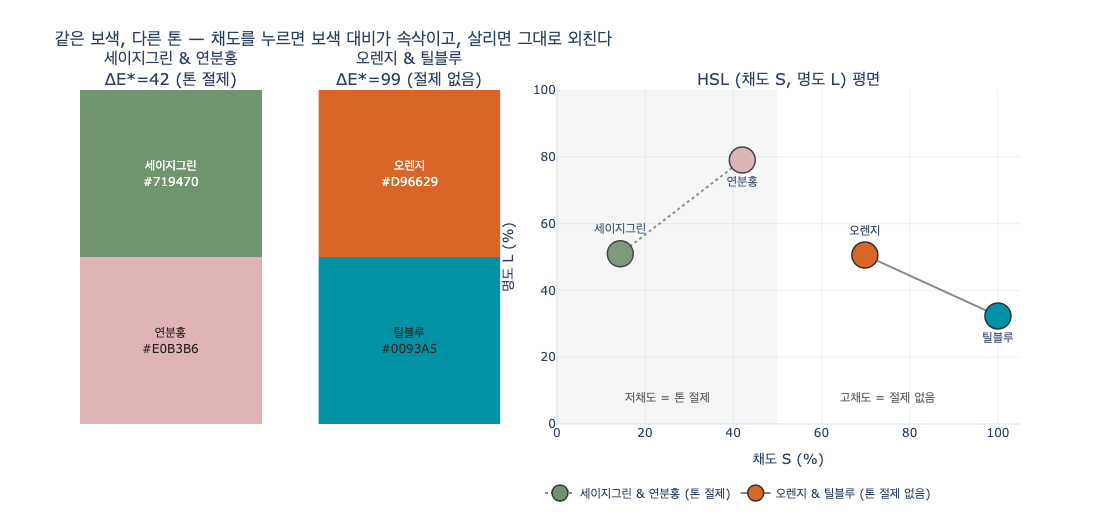

expy.png 저장 완료


In [5]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=1,
    cols=3,
    column_widths=[0.22, 0.22, 0.56],
    subplot_titles=[
        f"세이지그린 & 연분홍<br>ΔE*={results['세이지그린 & 연분홍 (톤 절제)']:.0f} (톤 절제)",
        f"오렌지 & 틸블루<br>ΔE*={results['오렌지 & 틸블루 (톤 절제 없음)']:.0f} (절제 없음)",
        "HSL (채도 S, 명도 L) 평면",
    ],
    horizontal_spacing=0.06,
)

# 스와치: 두 색을 위아래로 붙인 사각형
for col, (title, colors) in enumerate(PAIRS.items(), start=1):
    for i, (name, hx) in enumerate(colors):
        fig.add_shape(type="rect", x0=0, x1=1, y0=1 - i, y1=2 - i, fillcolor=hx, line_width=0, row=1, col=col)
        fig.add_annotation(
            x=0.5, y=1.5 - i, text=f"{name}<br>{hx}", showarrow=False, font=dict(size=12, color="white" if i == 0 else "#222"),
            row=1, col=col,
        )
    fig.update_xaxes(visible=False, range=[0, 1], row=1, col=col)
    fig.update_yaxes(visible=False, range=[0, 2], row=1, col=col)

# (S, L) 산점도
dash_styles = {"세이지그린 & 연분홍 (톤 절제)": "dot", "오렌지 & 틸블루 (톤 절제 없음)": "solid"}
for title, colors in PAIRS.items():
    pts = [hsl(hx) for _, hx in colors]
    fig.add_trace(
        go.Scatter(
            x=[p[1] for p in pts],
            y=[p[2] for p in pts],
            mode="lines+markers+text",
            line=dict(color="#888", dash=dash_styles[title], width=2),
            marker=dict(size=26, color=[hx for _, hx in colors], line=dict(color="#333", width=1.5)),
            text=[name for name, _ in colors],
            textposition=["top center", "bottom center"],
            textfont=dict(size=12),
            name=title,
            hovertemplate="%{text}<br>S=%{x:.1f}%<br>L=%{y:.1f}%<extra></extra>",
        ),
        row=1,
        col=3,
    )

# 저채도 영역 표시
fig.add_vrect(x0=0, x1=50, fillcolor="#bbb", opacity=0.15, line_width=0, row=1, col=3)
fig.add_annotation(x=25, y=8, text="저채도 = 톤 절제", showarrow=False, font=dict(color="#666", size=12), row=1, col=3)
fig.add_annotation(x=75, y=8, text="고채도 = 절제 없음", showarrow=False, font=dict(color="#666", size=12), row=1, col=3)

fig.update_xaxes(title_text="채도 S (%)", range=[0, 105], row=1, col=3)
fig.update_yaxes(title_text="명도 L (%)", range=[0, 100], row=1, col=3)
fig.update_layout(
    title_text="같은 보색, 다른 톤 — 채도를 누르면 보색 대비가 속삭이고, 살리면 그대로 외친다",
    template="plotly_white",
    width=1100,
    height=520,
    legend=dict(orientation="h", yanchor="bottom", y=-0.25, xanchor="center", x=0.7),
    margin=dict(t=90, b=90),
)

_show(fig)
fig.write_image("expy.png", scale=2)
print("expy.png 저장 완료")

## 정리

| | 세이지그린 & 연분홍 | 오렌지 & 틸블루 |
|---|---|---|
| 색상각 차이 $\Delta H$ | 약 $122°$ (보색 방향) | 약 $166°$ (거의 정확한 보색) |
| 평균 채도 (HSL) | **28%** — 톤 절제 | **85%** — 절제 없음 |
| 색차 $\Delta E^*_{ab}$ | **42** — 눌린 대비 | **99** — 강렬한 대비 |

보색이라는 **위치**는 같지만, **톤**을 어떻게 다루느냐가 인상을 결정한다.
채도를 낮추면 보색 대비가 "속삭이는" 조화(세이지그린·연분홍)가 되고,
채도를 그대로 두면 보색 대비가 "확실하게 자기 목소리를 내는" 틸 앤 오렌지가 된다.